# Oxygen Evals: Hood Canal-Sisters Point-Lynch Cove

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import cmocean.cm as cm
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import arrow
from collections import OrderedDict
from salishsea_tools import evaltools as et, viz_tools

In [2]:
with xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc') as mesh:
    deptht = mesh.gdept_1d[0].values
    tmask0 = mesh.tmask
    mbathy0 = mesh.mbathy
    long = mesh.nav_lon
    latg = mesh.nav_lat
with xr.open_dataset('/ocean/atall/MOAD/grid/bathymetry_202310b.nc') as bath:
    bathy = bath.Bathymetry

In [3]:
def plot_and_stats(temp1, name, idepth, jdepth, fig, ax, whichdepths, reverse, string, boxes=False, box=None, boxname=None):
    if boxes:
        corn = box
        select = temp1[(temp1.k >= idepth) & (temp1.k <= jdepth) &
                              (temp1.j >= corn[0]) & (temp1.j <= corn[1]) &
                              (temp1.i >= corn[2]) & (temp1.i <= corn[3]) &
                              (temp1[obsn] == temp1[obsn])]
        shift_text = 0.94
    else:
        print (temp1.keys())
        select = temp1[(temp1.k >= idepth) & (temp1.k < jdepth) & (temp1[obsn] == temp1[obsn])]
        shift_text = 1
    
    if reverse:
        one = modn
        two = obsn
    else:
        one = obsn
        two = modn
    
    counts, xedges, yedges, color = ax.hist2d(select[one], 
                                              select[two], 
                                           bins=np.arange(vmin, vmax, dbin), norm=LogNorm(), cmap=cmap);
    fig.colorbar(color, ax=ax)
   
    number, tbias = bias(select, one, two)
    trmse = rmse(select, one, two)
    tcrmse = crmse(trmse, tbias)
    tswillmott = swillmott(select, one, two)
#    m, c, syst, nonsyst = slope_inter(select, one, two)
    a1, b1, syst, nonsyst = wolfram_perp(select, one, two)
    tspread = spread(select, one, two)
    ax.plot([vmin, vmax], [vmin, vmax], 'k-');
    xr = np.arange(vmin, vmax, 0.5)
#    ax.plot(xr, c + m * xr, 'r-');
    ax.plot(xr, a1 + b1 * xr, 'r-')
    sc = scale/12
    sh = 2*sc-1
    bot = scale
    top = bot + 2*sh
    ax.arrow(sc+vmin, bot+vmin, 0, sh-np.abs(tbias)/2, head_width=0.5*sc, head_length=0.2*sc, length_includes_head=True)
    ax.arrow(sc+vmin, top+vmin, 0, -sh+np.abs(tbias)/2, head_width=0.5*sc, head_length=0.2*sc, length_includes_head=True)
    ax.arrow(2*sc+vmin, bot+vmin, 0, sh-syst/2, head_width=0.5*sc, head_length=0.2*sc, length_includes_head=True)
    ax.arrow(2*sc+vmin, top+vmin, 0, -sh+syst/2, head_width=0.5*sc, head_length=0.2*sc, length_includes_head=True)
    ax.arrow(3*sc+vmin, bot+vmin, 0, sh-nonsyst/2, head_width=0.5*sc, head_length=0.2*sc, length_includes_head=True)
    ax.arrow(3*sc+vmin, top+vmin, 0, -sh+nonsyst/2, head_width=0.5*sc, head_length=0.2*sc, length_includes_head=True);
    Cp2 = {'number': number,
            'bias': tbias,
          'rmse': trmse,
           'crmse': tcrmse,
          'swillmott': tswillmott,
          'slopedev': 1-b1,
          'const': a1,
          'systematic': syst,
          'nonsystematic': nonsyst,
          'spread': tspread}
    ax.text(0.8*sc+vmin, 0.9*bot*shift_text+vmin, 'bias', rotation=90)
    ax.text(1.8*sc+vmin, 0.72*bot*shift_text+vmin-shift_text, 'systematic', rotation=90)
    ax.text(2.8*sc+vmin, 0.6*bot*shift_text+vmin-shift_text, 'non-systematic', rotation=90)
    
    ax.set_title(f'{name}, {field} {whichdepths}{string}');
    dCp2 = pd.DataFrame(data=Cp2, index=[name])
    return dCp2, counts

def bias(df, obs, mod):
    diffy = df[mod] - df[obs]
    return diffy.count(), diffy.mean()
def rmse(df, obs, mod):
    return (np.sqrt(((df[mod] - df[obs])**2).mean()))

def crmse(rmse, bias):
    return (np.sqrt(rmse**2 - bias**2))

def swillmott(df, obs, mod):
    meanobs = df[obs].mean()
    return (((df[mod] - df[obs])**2).sum()
            /(( (df[mod] - meanobs).abs() + (df[obs] - meanobs).abs() )**2).sum())

def wolfram_perp(df, obsin, modin):
    
    mod = np.array(df[modin][(df[modin] == df[modin]) & (df[obsin] == df[obsin])])
    obs = np.array(df[obsin][(df[modin] == df[modin]) & (df[obsin] == df[obsin])])
    
    n = mod.shape[0]

    y2s = (mod**2).sum()
    ys = mod.sum()
    x2s = (obs**2).sum()
    xs = obs.sum()
    xys = (mod * obs).sum()
    B = 0.5 * ( (y2s - ys**2/n) - (x2s - xs**2/n)) / (xs * ys/n - xys)
    b1 = -B + np.sqrt(B*B + 1)
    a1 = (ys - b1*xs)/n
    predictions = a1 + b1 * df[obsin]
    
    nonsyst = np.sqrt(((df[modin] - predictions)**2).mean())
    systematic = np.sqrt(((predictions - df[obsin])**2).mean())
  
    return a1, b1, systematic, nonsyst
def spread(df, obs, mod):
    return 1 - ((df[mod] - df[mod].mean())**2).mean() / ((df[obs] - df[obs].mean())**2).mean() 



def read_pieces(pieces):
    temp1 = pd.read_csv(pieces[0])
    for piece in pieces[1:]:
        nextpiece = pd.read_csv(piece)
        if 'ferry' in piece:
            nextpiece['k'] = 0
        temp1 = pd.concat([temp1, nextpiece], ignore_index=True)
    return temp1


In [7]:
def stats_and_plot(years, idepth, jdepth, box, boxname, whichdepths):
    fig, axs = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'{boxname} Year {years[0]}-{years[-1]}')
    
    pieces1 = []
    for year in years:
        pieces1.append(
              f'/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_NewBathyHC_pnw_{year}0102_{year}1231.csv')
              #f'/ocean/atall/MOAD/ObsModel/202111/ObsModel_202111_ctd_from_UW_{year}0101_{year}1231.csv')
    temp1 = read_pieces(pieces1)
    alltogether, counts = plot_and_stats(temp1, '202410_NewBathy', jdepth, fig, axs[0], whichdepths, False, '', boxes=True, box=box, boxname=boxname)


    pieces2 = []
    for year in years:
        pieces2.append(
              f'/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_pnw_{year}0102_{year}1231.csv')
              #f'/ocean/atall/MOAD/ObsModel/202410/ObsModel_202410b_ctd_from_UW_{year}0101_{year}1231.csv')
    temp2 = read_pieces(pieces2)
    d202410, counts = plot_and_stats(temp2, '202410', idepth, jdepth, fig, axs[1], whichdepths, False, '', boxes=True, box=box, boxname=boxname)

    plot_profiles(temp1, temp2, axs[2], axs[3], box, boxname)

    alltogether = pd.concat([alltogether, d202410], axis=0)

In [8]:
def plot_profiles(temp1, temp2, ax, ax2, box, boxname):

    corn = box
    temp1['diff'] = temp1[modn] - temp1[obsn]
    select = temp1[(temp1.k >= idepth) & (temp1.k <= jdepth) &
                              (temp1.j >= corn[0]) & (temp1.j <= corn[1]) &
                              (temp1.i >= corn[2]) & (temp1.i <= corn[3]) &
                              (temp1[obsn] == temp1[obsn])]
    ks = (select.groupby('k')[obsn].mean().index[:])
    ax.plot(select.groupby('k')[obsn].mean(), deptht[ks], 'o-', c='k', label='Obs')
    ax.plot(select.groupby('k')[modn].mean(), deptht[ks], 'o-', c='tab:red', label='202111')
    ax2.plot(select.groupby('k')['diff'].mean(), deptht[ks], '-', c='tab:red', label='202111')
    ax.fill_betweenx(deptht[ks], select[['k', modn]].groupby('k').quantile(q=0.25)[modn], select[['k', modn]].groupby('k').quantile(q=0.75)[modn], alpha=0.2, color='tab:red')
    ax2.fill_betweenx(deptht[ks], select[['k', 'diff']].groupby('k').quantile(q=0.25)['diff'], select[['k', 'diff']].groupby('k').quantile(q=0.75)['diff'], alpha=0.2, color='tab:red')
    
    temp2['diff'] = temp2[modn] - temp2[obsn]
    select = temp2[(temp2.k >= idepth) & (temp2.k <= jdepth) &
                              (temp2.j >= corn[0]) & (temp2.j <= corn[1]) &
                              (temp2.i >= corn[2]) & (temp2.i <= corn[3]) &
                              (temp2[obsn] == temp2[obsn])]
    #ks = (select.groupby('k')[obsn].mean().index[:])
    ax.plot(select.groupby('k')[modn].mean(), deptht[ks], 'o-', c='tab:blue', label='202410')
    ax2.plot(select.groupby('k')['diff'].mean(), deptht[ks], '-', c='tab:blue', label='202410')
    ax.fill_betweenx(deptht[ks], select[['k', modn]].groupby('k').quantile(q=0.25)[modn], select[['k', modn]].groupby('k').quantile(q=0.75)[modn], alpha=0.2, color='tab:blue')
    ax.fill_betweenx(deptht[ks], select[['k', obsn]].groupby('k').quantile(q=0.25)[obsn], select[['k', obsn]].groupby('k').quantile(q=0.75)[obsn], alpha=0.2, color='k')
    ax2.fill_betweenx(deptht[ks], select[['k', 'diff']].groupby('k').quantile(q=0.25)['diff'], select[['k', 'diff']].groupby('k').quantile(q=0.75)['diff'], alpha=0.2, color='tab:blue')
    
    ax.invert_yaxis()
    ax2.invert_yaxis()
    
    ax.legend()
    ax2.legend()
    ax.set_title(f'{field} Profiles')
    ax2.set_title(f'{field} Difference Profiles')
    ax2.grid();

In [44]:
d202410b= pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_pnw_20150102_20151231.csv')
d202410NewBathy = pd.read_csv('/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_NewBathyHC_pnw_20150102_20151231.csv')

d202410b

,Unnamed: 0,dtUTC,Lon,Lat,Z,pressure (dbar),Temperature,Salinity,Oxygen_Dissolved,NO3,...,mod_silicon,mod_ammonium,mod_diatoms,mod_flagellates,mod_vosaline,mod_votemper,mod_total_alkalinity,mod_dissolved_inorganic_carbon,mod_dissolved_oxygen,k
0,1346776,2015-01-02,-124.75,48.51,227.0,227.000000,7.819199,33.872711,NaN,NaN,...,45.791023,0.030542,0.000589,0.004026,33.895290,7.701125,2314.384766,2287.840332,96.631172,31
1,1346908,2015-01-03,-124.75,48.51,227.0,227.000000,7.872204,33.864699,NaN,NaN,...,45.748955,0.033058,0.000605,0.004483,33.900539,7.687229,2314.757324,2287.864746,96.692406,31
2,1347048,2015-01-04,-124.75,48.51,227.0,227.000000,7.831757,33.874656,NaN,NaN,...,45.737495,0.031900,0.000627,0.004391,33.905952,7.693305,2315.020264,2288.028320,96.613983,31
3,1347185,2015-01-05,-124.75,48.51,227.0,227.000000,7.917117,33.855585,NaN,NaN,...,45.429661,0.030245,0.000590,0.004240,33.894886,7.771503,2314.514404,2286.342285,98.009499,31
4,1347317,2015-01-06,-124.75,48.51,227.0,227.000000,8.125404,33.808472,NaN,NaN,...,44.601097,0.032294,0.000810,0.004449,33.852493,7.962942,2312.557861,2281.509521,101.986938,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31408,1472050,2015-12-30,-124.90,49.82,174.0,175.567542,NaN,30.958888,NaN,NaN,...,56.213993,1.819623,0.022478,0.011294,30.953062,9.938076,2156.795410,2137.316895,96.491470,29
31409,1472051,2015-12-30,-124.90,49.82,175.0,176.836571,NaN,30.977390,NaN,NaN,...,56.213993,1.819623,0.022478,0.011294,30.953062,9.938076,2156.795410,2137.316895,96.491470,29
31410,1472055,2015-12-30,-124.87,49.84,314.0,317.143625,NaN,31.105642,NaN,NaN,...,58.552841,1.747009,0.007158,0.005625,31.088392,9.993499,2163.968750,2144.874512,90.455971,34
31411,1472056,2015-12-30,-124.87,49.84,316.0,319.006083,NaN,31.108183,NaN,NaN,...,58.552841,1.747009,0.007158,0.005625,31.088392,9.993499,2163.968750,2144.874512,90.455971,34


/tmp/ipykernel_223637/88358565.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax[0].pcolormesh(long, latg, bathy, cmap=cm.deep, vmin=0, vmax=100)
/tmp/ipykernel_223637/88358565.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im=ax[1].pcolormesh(long, latg, bathy, cmap=cm.deep, vmin=0, vmax=100)


Text(0, 0.5, 'Depth [m]')

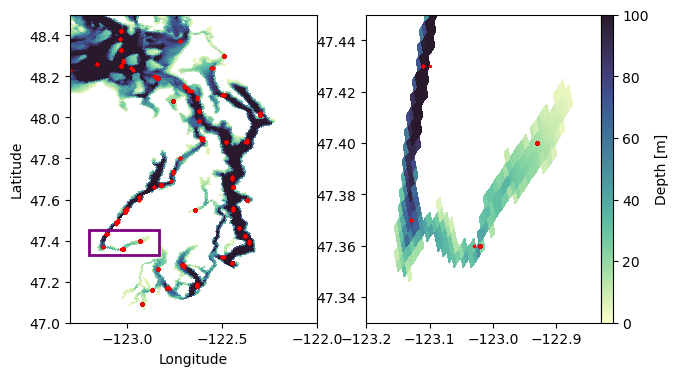

In [45]:
lon1, lon2 = (-123.2, -122.83)
lat1, lat2 = (47.33, 47.45)
fig, ax = plt.subplots(1,2,figsize=(7, 4))
ax[0].pcolormesh(long, latg, bathy, cmap=cm.deep, vmin=0, vmax=100)
ax[0].set_ylabel('Latitude')
ax[0].set_xlabel('Longitude')
ax[0].set_ylim([47,48.5])
ax[0].set_xlim([-123.3,-122])
# plot the location of observations
ax[0].scatter(d202410b.Lon, d202410b.Lat, color='r', s=2)
left, bottom, width, height = (lon2, lat1, lon1-lon2, lat2-lat1)
rect=mpatches.Rectangle((left,bottom),width,height, 
                    fill=False,
                    color="purple",
                    linewidth=2,
                    label="Puget Sound")
  
ax[0].add_patch(rect)
im=ax[1].pcolormesh(long, latg, bathy, cmap=cm.deep, vmin=0, vmax=100)
ax[1].set_ylim([lat1,lat2])
ax[1].set_xlim([lon1,lon2])
ax[1].scatter(d202410b.Lon, d202410b.Lat, color='r', s=2)


divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size='5%', pad=0.002)
cbar=fig.colorbar(im, cax=cax, orientation='vertical')
cbar.ax.set_ylabel('Depth [m]')


TypeError: plot_and_stats() missing 1 required positional argument: 'string'

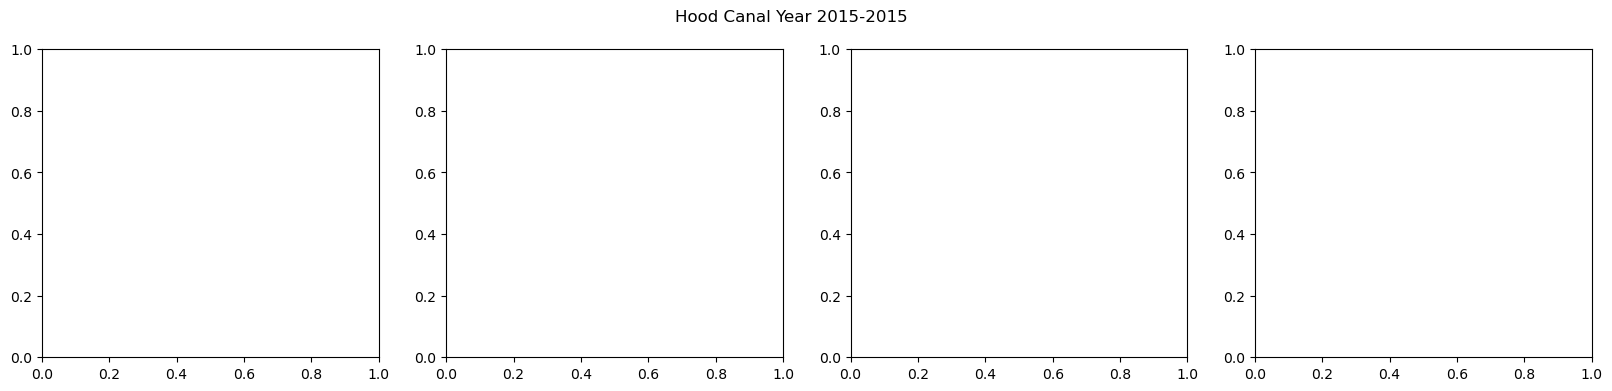

In [46]:
cmap = cm.rain #'pink_r'#cm.rain #cm.ice_r #'ocean_r' #'pink_r'
Hood_Canal = [75, 150, 90, 200]
idepth = 0
jdepth = 39

field = 'Salinity'
obsn = 'Salinity'
modn = 'mod_vosaline'
vmax = 34
vmin = 0
dbin = 0.5
scale = 24

stats_and_plot([2015],
               idepth, jdepth, Hood_Canal, 'Hood Canal', 'alldepths')

field = 'Temperature'
obsn = 'Temperature'
modn = 'mod_votemper'
vmax = 30
vmin = 0
dbin = 0.5
scale = 24

stats_and_plot([2015],
               idepth, jdepth, Hood_Canal, 'Hood Canal', 'alldepths')

field = 'Dissolved Oxygen'
obsn = 'Oxygen_Dissolved'
modn = 'mod_dissolved_oxygen'
vmax = 500
vmin = 0
dbin = 10
scale = 260
stats_and_plot([2015],
               idepth, jdepth, Hood_Canal, 'Hood Canal', 'alldepths')

field = 'Nitrate'
obsn = 'NO3'
modn = 'mod_nitrate'
vmax = 40
vmin = 0
dbin = 1
scale = 30
stats_and_plot([2015],
               idepth, jdepth, Hood_Canal, 'Hood Canal', 'alldepths')

field = 'DIC'
obsn = 'DIC (uM)'
modn = 'mod_dissolved_inorganic_carbon'
vmax = 2500
vmin = 1000
dbin = 50
scale = 1000
stats_and_plot([2015],
               idepth, jdepth, Hood_Canal, 'Hood Canal', 'alldepths')



### About Lynch Cove and Sisters point

In [ ]:
d202410 = d202410b
d202410.loc[((d202410['Lat'] >= lat1) & (d202410['Lat'] <= lat2) & (d202410['Lon'] <= lon2) & (d202410['Lon'] >= lon1)),['broadregions']]='HC'
d202410.loc[((d202410['Lat'] >= lat1) & (d202410['Lat'] <= 47.37) & (d202410['Lon'] <= -123) & (d202410['Lon'] >= -123.05)),['broadregions']]='SP'
d202410.loc[((d202410['Lat'] >= lat1) & (d202410['Lat'] <= 47.40) & (d202410['Lon'] <= -122.90) & (d202410['Lon'] >= -122.95)),['broadregions']]='LC'
d202410.broadregions.unique()

d202410N = d202410NewBathy
d202410N.loc[((d202410N['Lat'] >= lat1) & (d202410N['Lat'] <= lat2) & (d202410N['Lon'] <= lon2) & (d202410N['Lon'] >= lon1)),['broadregions']]='HC_NewBathy'
d202410N.loc[((d202410N['Lat'] >= 48.9) & (d202410N['Lat'] <= 49.1) & (d202410N['Lon'] <= -123.35) & (d202410N['Lon'] >= -123.5)),['broadregions']]='SP_NewBathy'
d202410N.loc[((d202410N['Lat'] >= lat1) & (d202410N['Lat'] <= 47.40) & (d202410N['Lon'] <= -122.90) & (d202410N['Lon'] >= -122.95)),['broadregions']]='LC_NewBathy'
d202410N.broadregions.unique()

<ArrowStringArray>
[nan, 'HC_NewBathy', 'LC_NewBathy', 'SP_NewBathy']
Length: 4, dtype: str

In [ ]:
d202410['Month']=d202410['dtUTC'].astype(str).str[5:7]
d202410N['Month']=d202410N['dtUTC'].astype(str).str[5:7]

In [ ]:
HC=d202410.loc[d202410['broadregions']=='HC']
SP=d202410.loc[d202410['broadregions']=='SP']
LC=d202410.loc[d202410['broadregions']=='LC']
reg=HC
DJF=reg.loc[(reg.Month=='12')|(reg.Month=='01')|(reg.Month=='02')]
MAM=reg.loc[(reg.Month=='03')|(reg.Month=='04')|(reg.Month=='05')]
JJA=reg.loc[(reg.Month=='06')|(reg.Month=='07')|(reg.Month=='08')]
SON=reg.loc[(reg.Month=='09')|(reg.Month=='10')|(reg.Month=='11')]

HC_N=d202410N.loc[d202410N['broadregions']=='HC_NewBathy']
SP_N=d202410N.loc[d202410N['broadregions']=='SP_NewBathy']
LC_N=d202410N.loc[d202410N['broadregions']=='LC_NewBathy']
reg_N=HC_N
DJF_N=reg_N.loc[(reg_N.Month=='12')|(reg_N.Month=='01')|(reg_N.Month=='02')]
MAM_N=reg_N.loc[(reg_N.Month=='03')|(reg_N.Month=='04')|(reg_N.Month=='05')]
JJA_N=reg_N.loc[(reg_N.Month=='06')|(reg_N.Month=='07')|(reg_N.Month=='08')]
SON_N=reg_N.loc[(reg_N.Month=='09')|(reg_N.Month=='10')|(reg_N.Month=='11')]

In [ ]:
reg['DIC (uM)']

1549    NaN
1556    NaN
1565    NaN
1574    NaN
1583    NaN
         ..
28696   NaN
28700   NaN
28704   NaN
28708   NaN
28712   NaN
Name: DIC (uM), Length: 616, dtype: float64

In [47]:
dreg=dict()
dreg_N=dict()
for iregion in reg.broadregions.dropna().unique():
    dreg[iregion] = reg.loc[reg.broadregions==iregion]  
for iregion in reg_N.broadregions.dropna().unique():
    dreg_N[iregion] = reg_N.loc[reg_N.broadregions==iregion]
statsubs=OrderedDict({'All':reg,
                      'z < 20 m':reg.loc[reg.Z<20],
                      '20 m < z < 50 m':reg.loc[(reg.Z>=20)&(reg.Z<50)],
                      '50 m < z < 100 m':reg.loc[(reg.Z>=50)&(reg.Z<100)],
                      'z >= 100 m':reg.loc[reg.Z>=100],
                      'WINTER':DJF,
                      'SPRING':MAM,
                      'SUMMER':JJA,
                      'FALL': SON,})
statsubs_N=OrderedDict({'All':reg_N,
                      'z < 20 m':reg_N.loc[reg_N.Z<20],
                      '20 m < z < 50 m':reg_N.loc[(reg_N.Z>=20)&(reg_N.Z<50)],
                      '50 m < z < 100 m':reg_N.loc[(reg_N.Z>=50)&(reg_N.Z<100)],
                      'z >= 100 m':reg_N.loc[reg_N.Z>=100],
                      'WINTER':DJF_N,
                      'SPRING':MAM_N,
                      'SUMMER':JJA_N,
                      'FALL': SON_N,})
for iregion in reg.broadregions.dropna().unique():
    statsubs[iregion]=dreg[iregion]
for iregion in reg_N.broadregions.dropna().unique():
    statsubs_N[iregion]=dreg_N[iregion]
statsubs.keys()
statsubs_N.keys()

odict_keys(['All', 'z < 20 m', '20 m < z < 50 m', '50 m < z < 100 m', 'z >= 100 m', 'WINTER', 'SPRING', 'SUMMER', 'FALL', 'HC_NewBathy'])

In [48]:
def bySeason(ax,obsvar,modvar,lims):
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect(1)
    ax.set_xlabel('Obs',fontsize=15)
    ax.set_ylabel('202410',fontsize=15)
    SS=et.varvarPlot(ax,DJF,obsvar,modvar,cols='b')
    SS=et.varvarPlot(ax,MAM,obsvar,modvar,cols='c')
    SS=et.varvarPlot(ax,JJA,obsvar,modvar,cols='r')
    SS=et.varvarPlot(ax,SON,obsvar,modvar,cols='m')
    ax.plot(lims,lims,'k-') 
    return 
def bySeason_N(ax,obsvar,modvar,lims):
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect(1)
    ax.set_xlabel('Obs',fontsize=15)
    ax.set_ylabel('202410_NewBathy',fontsize=15)
    SS=et.varvarPlot(ax,DJF_N,obsvar,modvar,cols='b')
    SS=et.varvarPlot(ax,MAM_N,obsvar,modvar,cols='c')
    SS=et.varvarPlot(ax,JJA_N,obsvar,modvar,cols='r')
    SS=et.varvarPlot(ax,SON_N,obsvar,modvar,cols='m')
    ax.plot(lims,lims,'k-') 
    return

Text(0.5, 1.0, 'Nitrate (uM)')

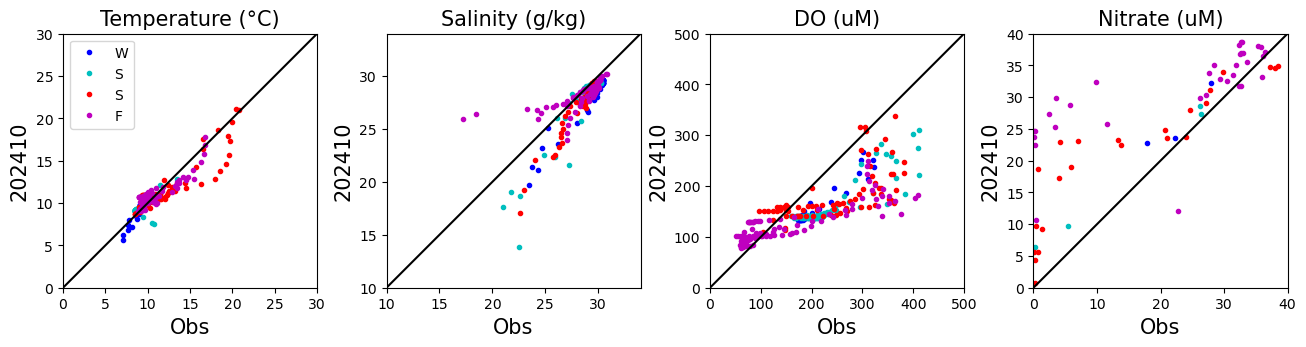

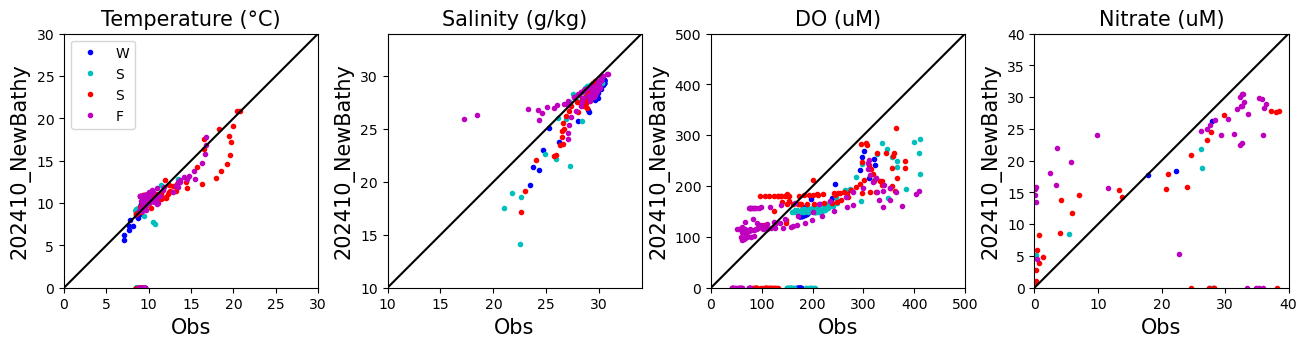

In [49]:
fig, ax = plt.subplots(1,4,figsize = (16,3.3))
bySeason(ax[0],'Temperature','mod_votemper',(0,30))
ax[0].set_title('Temperature (°C)',fontsize=15)
#ax[0].legend('WINTER','SPRING','SUMMER','FALL')
ax[0].legend('WSSF')
bySeason(ax[1],'Salinity','mod_vosaline',(10,34))
ax[1].set_title('Salinity (g/kg)',fontsize=15)
bySeason(ax[2],'Oxygen_Dissolved','mod_dissolved_oxygen',(0,500))
ax[2].set_title('DO (uM)',fontsize=15)
bySeason(ax[3],'NO3','mod_nitrate',(0,40))
ax[3].set_title('Nitrate (uM)',fontsize=15)

fig, ax = plt.subplots(1,4,figsize = (16,3.3))
bySeason_N(ax[0],'Temperature','mod_votemper',(0,30))
ax[0].set_title('Temperature (°C)',fontsize=15)
ax[0].legend('WSSF')
bySeason_N(ax[1],'Salinity','mod_vosaline',(10,34))
ax[1].set_title('Salinity (g/kg)',fontsize=15)
bySeason_N(ax[2],'Oxygen_Dissolved','mod_dissolved_oxygen',(0,500))
ax[2].set_title('DO (uM)',fontsize=15)
bySeason_N(ax[3],'NO3','mod_nitrate',(0,40))
ax[3].set_title('Nitrate (uM)',fontsize=15)

In [54]:
HC24 = d202410[ d202410['Lon'].between(lon1, lon2) & d202410['Lat'].between(lat1, lat2) ]
SP24 = d202410[ d202410['Lon'].between(-123.1, -122.95) & d202410['Lat'].between(lat1, 47.43) ]
LC24 = d202410[ d202410['Lon'].between(-122.95, lon2) & d202410['Lat'].between(lat1, 47.43) ]

HC24N = d202410N[ d202410N['Lon'].between(lon1, lon2) & d202410N['Lat'].between(lat1, lat2) ]
SP24N = d202410N[ d202410N['Lon'].between(-123.1, -122.95) & d202410N['Lat'].between(lat1, 47.43) ]
LC24N = d202410N[ d202410N['Lon'].between(-122.95, lon2) & d202410N['Lat'].between(lat1, 47.43) ]

In [55]:
SP24["dtUTC"] = pd.to_datetime(SP24["dtUTC"], errors='coerce')
LC24["dtUTC"] = pd.to_datetime(LC24["dtUTC"], errors='coerce')
SP24N["dtUTC"] = pd.to_datetime(SP24N["dtUTC"], errors='coerce')
LC24N["dtUTC"] = pd.to_datetime(LC24N["dtUTC"], errors='coerce')

Text(0.5, 1.0, 'Lynch Cove')

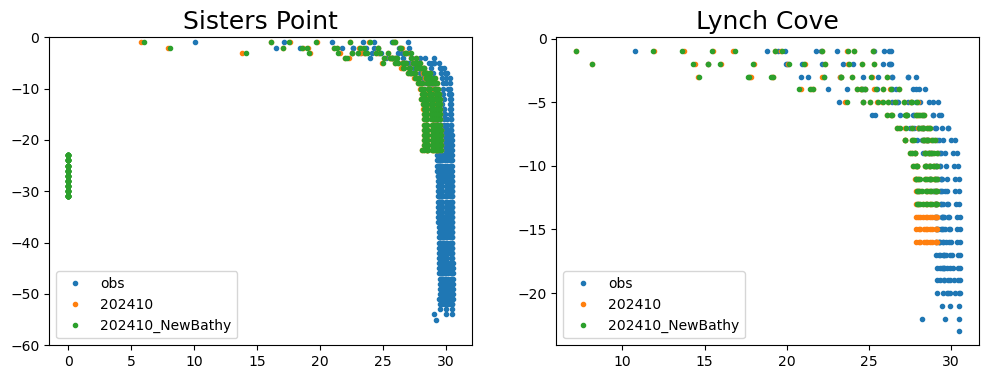

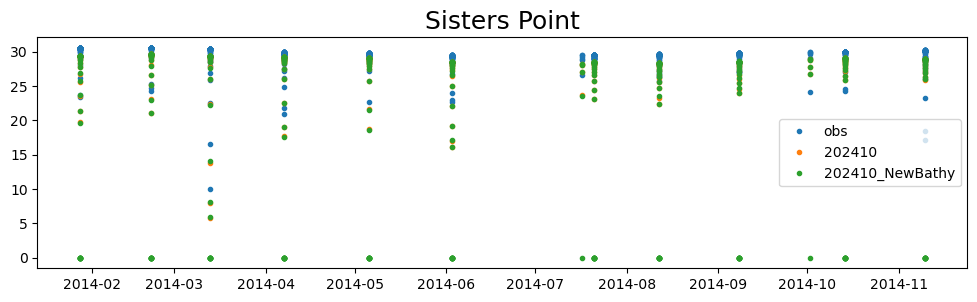

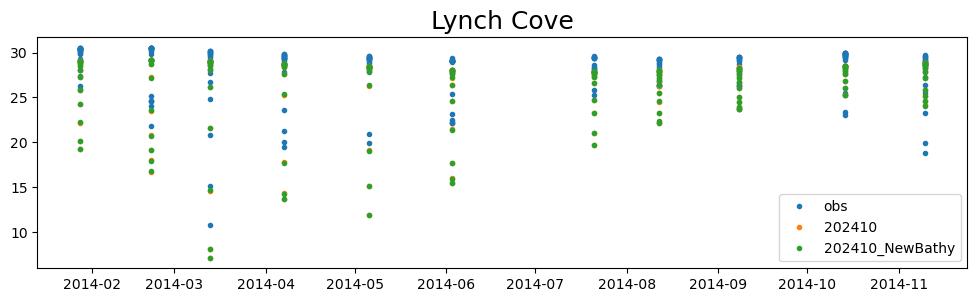

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(SP24.Salinity,-SP24.Z, '.',label='obs')
ax[0].plot(SP24.mod_vosaline,-SP24.Z, '.', label='202410')
ax[0].plot(SP24N.mod_vosaline,-SP24N.Z, '.', label='202410_NewBathy')
ax[0].set_title('Sisters Point',fontsize=18)
ax[0].set_ylim(-60,0)
ax[1].plot(LC24.Salinity,-LC24.Z, '.',label='obs')
ax[1].plot(LC24.mod_vosaline,-LC24.Z, '.', label='202410')
ax[1].plot(LC24N.mod_vosaline,-LC24N.Z, '.', label='202410_NewBathy')
ax[0].legend()
ax[1].legend()
ax[1].set_title('Lynch Cove',fontsize=18)
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(SP24.dtUTC,SP24.Salinity, '.',label='obs')
ax.plot(SP24.dtUTC,SP24.mod_vosaline, '.', label='202410')
ax.plot(SP24N.dtUTC,SP24N.mod_vosaline, '.', label='202410_NewBathy')
ax.legend()
ax.set_title('Sisters Point',fontsize=18)
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(LC24.dtUTC,LC24.Salinity, '.',label='obs')
ax.plot(LC24.dtUTC,LC24.mod_vosaline, '.', label='202410')
ax.plot(LC24N.dtUTC,LC24N.mod_vosaline, '.', label='202410_NewBathy')
ax.legend()
ax.set_title('Lynch Cove',fontsize=18)

Text(0.5, 1.0, 'Lynch Cove')

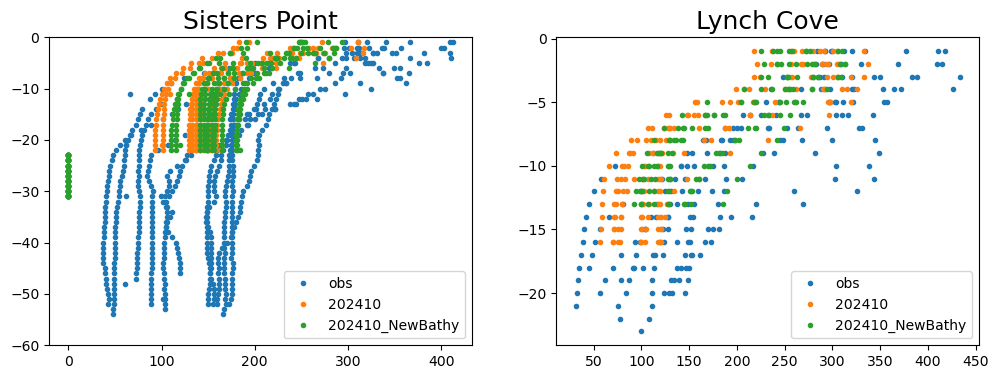

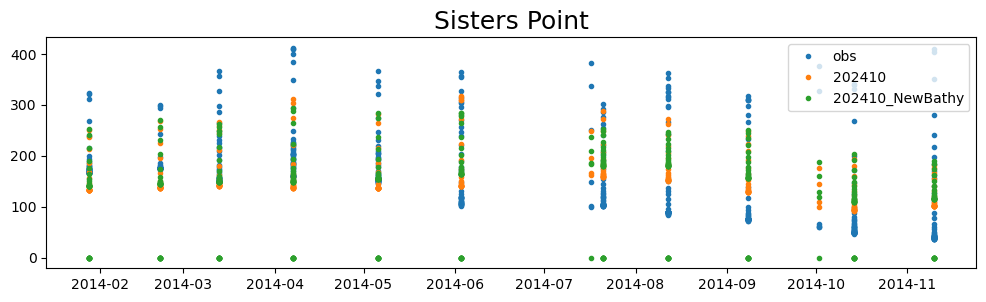

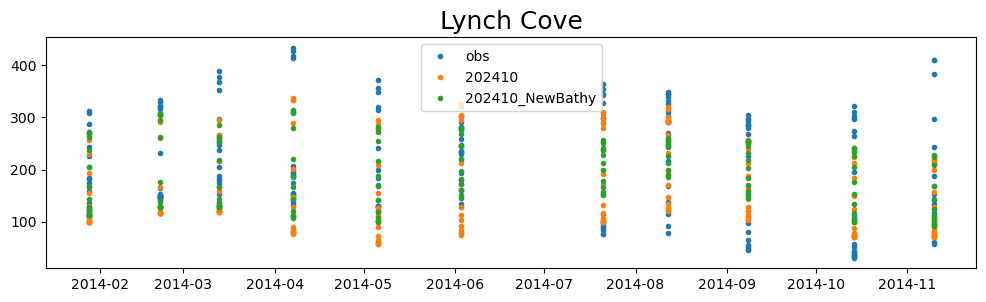

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(SP24.Oxygen_Dissolved,-SP24.Z, '.',label='obs')
ax[0].plot(SP24.mod_dissolved_oxygen,-SP24.Z, '.', label='202410')
ax[0].plot(SP24N.mod_dissolved_oxygen,-SP24N.Z, '.', label='202410_NewBathy')
ax[0].set_title('Sisters Point',fontsize=18)
ax[0].set_ylim(-60,0)
ax[1].plot(LC24.Oxygen_Dissolved,-LC24.Z, '.',label='obs')
ax[1].plot(LC24.mod_dissolved_oxygen,-LC24.Z, '.', label='202410')
ax[1].plot(LC24N.mod_dissolved_oxygen,-LC24N.Z, '.', label='202410_NewBathy')
ax[0].legend()
ax[1].legend()
ax[1].set_title('Lynch Cove',fontsize=18)
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(SP24.dtUTC,SP24.Oxygen_Dissolved, '.',label='obs')
ax.plot(SP24.dtUTC,SP24.mod_dissolved_oxygen, '.', label='202410')
ax.plot(SP24N.dtUTC,SP24N.mod_dissolved_oxygen, '.', label='202410_NewBathy')
ax.legend()
ax.set_title('Sisters Point',fontsize=18)
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(LC24.dtUTC,LC24.Oxygen_Dissolved, '.',label='obs')
ax.plot(LC24.dtUTC,LC24.mod_dissolved_oxygen, '.', label='202410')
ax.plot(LC24N.dtUTC,LC24N.mod_dissolved_oxygen, '.', label='202410_NewBathy')
ax.legend()
ax.set_title('Lynch Cove',fontsize=18)

In [31]:
grid_dir = Path("/ocean/atall/MOAD/grid/")
grid_map = Path("grid_from_lat_lon_mask999.nc")
grid_lons_lats = xr.open_dataset(grid_dir / grid_map)

In [32]:
j_Sis = grid_lons_lats.jj.sel(lats=47.356205, lons=-123.02487, method='nearest') # 37 m (Obs)
i_Sis = grid_lons_lats.ii.sel(lats=47.356205, lons=-123.02487, method='nearest')
j_LyC = grid_lons_lats.jj.sel(lats=47.39814833, lons=-122.92959167, method='nearest') # 19 m (Obs)
i_LyC = grid_lons_lats.ii.sel(lats=47.39814833, lons=-122.92959167, method='nearest')
print(bathy[j_Sis, i_Sis+1], bathy[j_LyC, i_LyC-1])
#_Sis = i_Sis+1
#_LyC = i_LyC-2

<xarray.DataArray 'Bathymetry' ()> Size: 8B
array(48.3125)
Coordinates:
    lons     float64 8B -123.0
    lats     float64 8B 47.36
Attributes:
    units:      metres
    long_name:  sea_floor_depth <xarray.DataArray 'Bathymetry' ()> Size: 8B
array(20.6875)
Coordinates:
    lons     float64 8B -122.9
    lats     float64 8B 47.4
Attributes:
    units:      metres
    long_name:  sea_floor_depth


Text(0.5, 1.0, 'Obs-Lynch Cove')

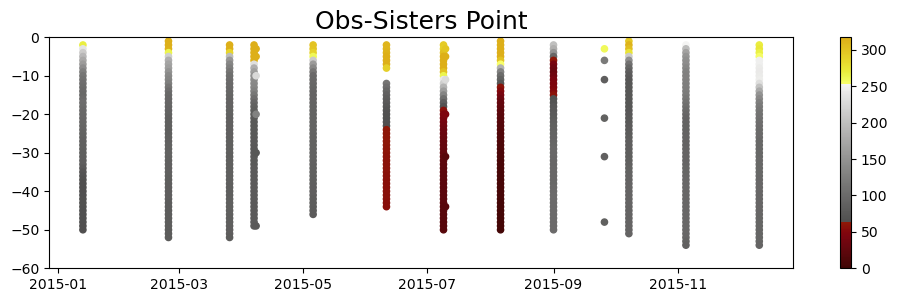

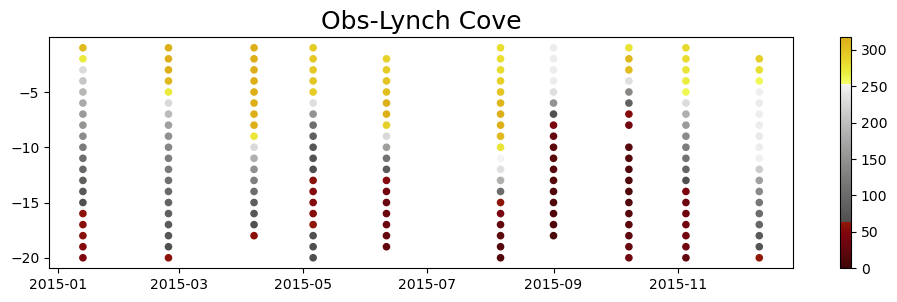

In [33]:

fig, ax = plt.subplots(1, 1, figsize=(12, 3))
sc = ax.scatter(SP24.dtUTC, -SP24.Z, c=SP24.Oxygen_Dissolved, vmin=0, vmax=317, s=20, cmap=cm.oxy)
plt.colorbar(sc)
ax.set_ylim(-60,0)
ax.set_title('Obs-Sisters Point',fontsize=18)
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
sc = ax.scatter(LC24.dtUTC, -LC24.Z, c=LC24.Oxygen_Dissolved, vmin=0, vmax=317, s=20, cmap=cm.oxy)
plt.colorbar(sc)
ax.set_title('Obs-Lynch Cove',fontsize=18)

AttributeError: 'DataFrame' object has no attribute 'SA'

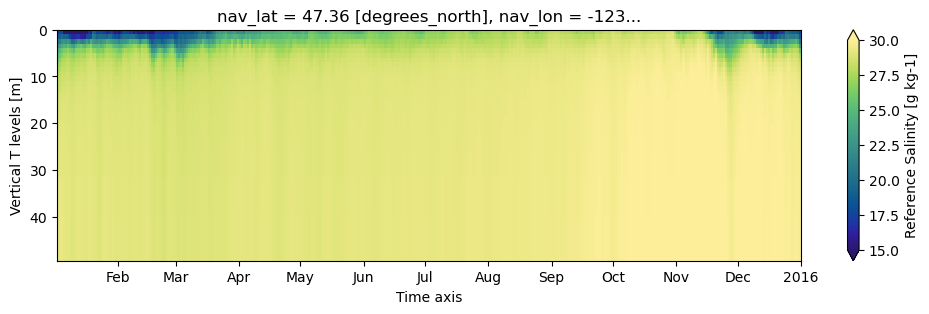

In [35]:
syear = 2015
eyear = 2015
smonth = 1
emonth = 12
startdate = arrow.get(syear, smonth, 2)
enddate = arrow.get(eyear, emonth, 31)
dir = '/ocean/atall/MOAD/Model/202410b_NewBathyHC/'
for ii in range(2):
    fig, axs = plt.subplots(1, 1, figsize=(12, 3))
    if ii==0:
        KK, JJ, II = (np.array(mbathy0[0,j_Sis,i_Sis]), j_Sis, i_Sis)
    else:
        KK, JJ, II = (np.array(mbathy0[0,j_LyC,i_LyC]), j_LyC, i_LyC)
    first=True
    for iii, day in enumerate(arrow.Arrow.range('day', startdate, enddate)):
        year = day.year
        yr2 = day.strftime("%y")
        month = day.month
        Month = day.strftime("%b").lower()
        day = day.day
        # set up filename to follow NEMO conventions
        fgrdT = f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_grid_T.nc'
        with xr.open_dataset(fgrdT) as ds_grdT:
            sal0 = ds_grdT['vosaline'][:,:KK,JJ,II]
        if first:
            first = False
            sal = sal0
        else:
            sal = xr.concat([sal, sal0], dim='time_counter')
    sal.plot(ax=axs, y="deptht",yincrease=False, vmin=15, vmax=30, cmap=cm.haline)
    if ii==0:
        axs.scatter(SP24.dtUTC, SP24.Z, c=SP24.SA, vmin=15, vmax=30, s=20, cmap=cm.haline, edgecolor='r')
        axs.set_title('Sisters Point',fontsize=18)
    else:
        axs.scatter(LC24.dtUTC, LC24.Z, c=LC24.SA, vmin=15, vmax=30, s=20, cmap=cm.haline, edgecolor='r')
        axs.set_title('Lynch Cove',fontsize=18)


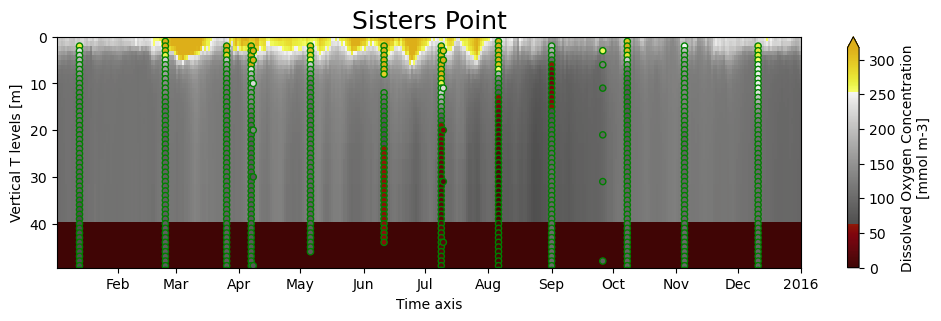

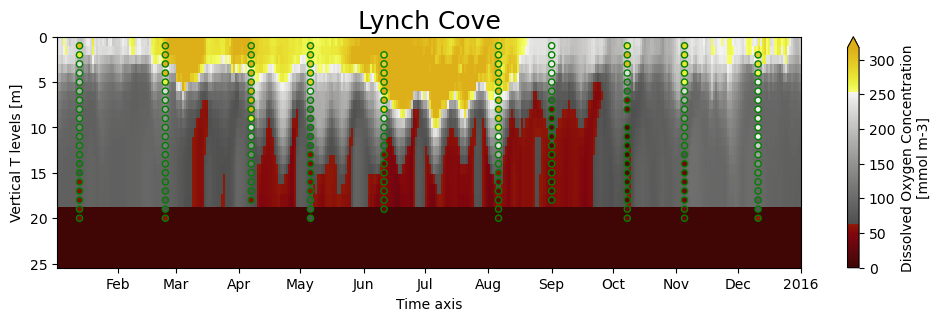

In [36]:
syear = 2015
eyear = 2015
smonth = 1
emonth = 12
startdate = arrow.get(syear, smonth, 2)
enddate = arrow.get(eyear, emonth, 31)
dir = '/ocean/atall/MOAD/Model/202410b/oxygen/'
for ii in range(2):
    fig, axs = plt.subplots(1, 1, figsize=(12, 3))
    if ii==0:
        KK, JJ, II = (np.array(mbathy0[0,j_Sis,i_Sis]), j_Sis, i_Sis)
    else:
        KK, JJ, II = (np.array(mbathy0[0,j_LyC,i_LyC]), j_LyC, i_LyC)
    first=True
    for iii, day in enumerate(arrow.Arrow.range('day', startdate, enddate)):
        year = day.year
        yr2 = day.strftime("%y")
        month = day.month
        Month = day.strftime("%b").lower()
        day = day.day
        # set up filename to follow NEMO conventions
        fchem = f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_chem_T.nc'
        with xr.open_dataset(fchem) as ds_chem:
            oxy0 = ds_chem['dissolved_oxygen'][:,:KK,JJ,II]
        if first:
            first = False
            oxy = oxy0
        else:
            oxy = xr.concat([oxy, oxy0], dim='time_counter')
    oxy.plot(ax=axs, y="deptht",yincrease=False, vmin=0, vmax=317, cmap=cm.oxy)
    if ii==0:
        axs.scatter(SP24.dtUTC, SP24.Z, c=SP24.Oxygen_Dissolved, vmin=0, vmax=317, s=20, cmap=cm.oxy, edgecolor='g')
        axs.set_title('Sisters Point',fontsize=18)
    else:
        axs.scatter(LC24.dtUTC, LC24.Z, c=LC24.Oxygen_Dissolved, vmin=0, vmax=317, s=20, cmap=cm.oxy, edgecolor='g')
        axs.set_title('Lynch Cove',fontsize=18)


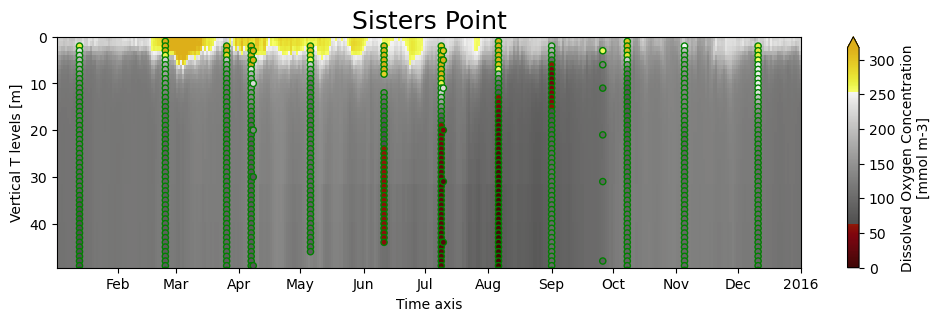

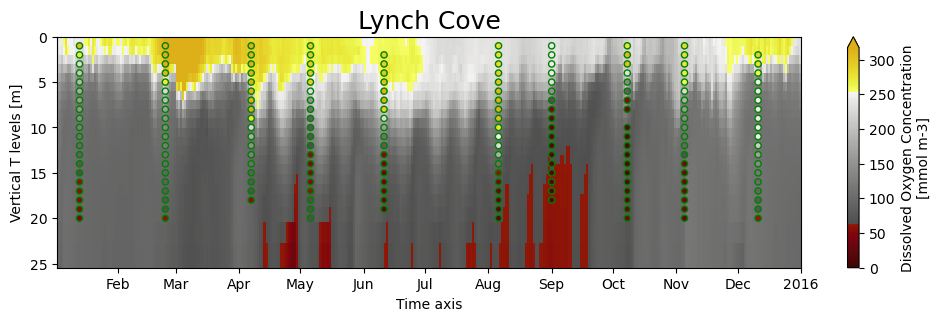

In [34]:
syear = 2015
eyear = 2015
smonth = 1
emonth = 12
startdate = arrow.get(syear, smonth, 2)
enddate = arrow.get(eyear, emonth, 31)
dir = '/ocean/atall/MOAD/Model/202410b_NewBathyHC/'
for ii in range(2):
    fig, axs = plt.subplots(1, 1, figsize=(12, 3))
    if ii==0:
        KK, JJ, II = (np.array(mbathy0[0,j_Sis,i_Sis]), j_Sis, i_Sis)
    else:
        KK, JJ, II = (np.array(mbathy0[0,j_LyC,i_LyC]), j_LyC, i_LyC)
    first=True
    for iii, day in enumerate(arrow.Arrow.range('day', startdate, enddate)):
        year = day.year
        yr2 = day.strftime("%y")
        month = day.month
        Month = day.strftime("%b").lower()
        day = day.day
        # set up filename to follow NEMO conventions
        fchem = f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_chem_T.nc'
        with xr.open_dataset(fchem) as ds_chem:
            oxy0 = ds_chem['dissolved_oxygen'][:,:KK,JJ,II]
        if first:
            first = False
            oxy = oxy0
        else:
            oxy = xr.concat([oxy, oxy0], dim='time_counter')
    oxy.plot(ax=axs, y="deptht",yincrease=False, vmin=0, vmax=317, cmap=cm.oxy)
    if ii==0:
        axs.scatter(SP24.dtUTC, SP24.Z, c=SP24.Oxygen_Dissolved, vmin=0, vmax=317, s=20, cmap=cm.oxy, edgecolor='g')
        axs.set_title('Sisters Point',fontsize=18)
    else:
        axs.scatter(LC24.dtUTC, LC24.Z, c=LC24.Oxygen_Dissolved, vmin=0, vmax=317, s=20, cmap=cm.oxy, edgecolor='g')
        axs.set_title('Lynch Cove',fontsize=18)
